# Ad Marketing Strategy A/B Test & Rollout Decision

**Business question.** Two new ad targeting strategies were tested against the current one (control). Does either strategy raise click-through rate enough to justify a rollout, does the gain hold up over time, and how much traffic should move?

**Data.** Public Tianchi *Audience Expansion Dataset*, file `effect_tb.csv` (ad click log). This notebook runs on the **full 2,645,958-row file** (2,219,999 records after cleaning). Every number below is computed on the full file.

**How to rerun on the full file.** Change `DATA_PATH` in the config cell to point at the 200,000-row sample to reproduce the development run. The loader detects whether the file has a header row.

**Structure**

1. Experiment design (written before looking at outcomes)
2. Setup
3. Data loading and schema verification
4. Cleaning
5. Power analysis
6. Randomization and data-quality checks
7. Hypothesis tests (formula and statsmodels, side by side)
8. Robustness: does the effect hold on both days?
9. Impact estimate
10. Decision memo
11. Exports for Power BI
12. Summary, limitations, next steps

## 1. Experiment design (pre-registered)

This section is fixed **before any outcome data is examined**. Writing the hypotheses, metric, significance level and decision rules first prevents choosing them after seeing which comparison looks good (p-hacking).

| Element | Choice |
|---|---|
| Arms | Control (current strategy), Strategy 1, Strategy 2 |
| Unit of analysis | One user-day record (the dataset logs whether a user clicked the ad on a given day) |
| Primary metric | **CTR** = clicked records / all records in the arm |
| Primary comparisons | Strategy 1 vs Control, Strategy 2 vs Control |
| Tie-break comparison | Strategy 2 vs Strategy 1 (only used to pick a winner if both beat control) |
| Hypotheses (each comparison) | H0: p_treatment = p_control; H1: p_treatment ≠ p_control (two-sided) |
| Significance | Family-wise α = 0.05 across 3 comparisons, **Bonferroni α = 0.05 / 3 = 0.0167** per test |
| Power | 0.80 |
| MDE | **5% relative lift** in CTR: the smallest gain worth the switching cost (agreed with the business side up front) |
| Test | Two-proportion z-test (large samples, binary outcome: the normal approximation to the binomial is accurate) |
| Pre-declared robustness check | Effect direction must be the same on each logged day (time consistency) |

**Pre-declared decision rules**

- **Launch** a strategy only if (a) it beats control at the Bonferroni level, (b) its point lift is at least the 5% MDE, and (c) the lift is positive on every day.
- If (a) holds but (c) fails, the result is **not stable**: do not launch on this evidence.
- If both strategies qualify, pick the one that wins the tie-break comparison.

Why Bonferroni: three tests at α = 0.05 each would give up to a ~14% chance of at least one false positive. Bonferroni is conservative, simple to explain, and with effects of the size seen here it does not change any conclusion.

## 2. Setup & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.contingency_tables import StratifiedTable
import os

# Data path: swap to 'effect_tb.csv' to run the full dataset
DATA_PATH = 'effect_tb_full.csv'
OUTPUT_DIR = './powerbi_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Pre-registered design parameters (Section 1)
ALPHA_FAMILY = 0.05
N_COMPARISONS = 3
ALPHA = ALPHA_FAMILY / N_COMPARISONS
POWER = 0.80
MDE_REL = 0.05

# Arm labels from the dataset documentation (dmp_id coding)
ARM_NAMES = {1: 'Control', 2: 'Strategy 1', 3: 'Strategy 2'}

# Chart style: one consistent, colorblind-validated palette
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
ARM_COLORS = {'Control': BLUE, 'Strategy 1': ORANGE, 'Strategy 2': AQUA}
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.edgecolor': GRID, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2, 'axes.grid': True, 'grid.color': GRID,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'axes.axisbelow': True,
})
pd.set_option('display.float_format', lambda v: f'{v:,.6g}')

## 3. Data loading & schema verification

**Question:** What does each column actually mean? Getting this wrong invalidates everything downstream.

The sample file carries the header `strategy, user_id, click, channel`. The dataset's own documentation lists the columns of `effect_tb.csv` in this order:

| Position | Official name | Meaning |
|---|---|---|
| 1 | `dt` | Log day indicator |
| 2 | `user_id` | User ID |
| 3 | `label` | Clicked the ad that day (1) or not (0) |
| 4 | `dmp_id` | **Marketing strategy arm: 1 = control, 2 = strategy 1, 3 = strategy 2** |

So the column labeled `channel` in the sample is the **experiment arm**, and the column labeled `strategy` is the **day**. The check below confirms it: the arm shares in the sample match the documented full-data arm sizes (1,905,663 / 411,107 / 316,205 after deduplication) almost exactly.

In [2]:
# Read by position: skip the header row if there is one (the original effect_tb.csv has none)
first_line = open(DATA_PATH).readline()
has_header = any(ch.isalpha() for ch in first_line)
df_raw = pd.read_csv(DATA_PATH, header=None, skiprows=1 if has_header else 0,
                     names=['day', 'user_id', 'click', 'arm_id'])
print(f"Header row detected: {has_header} ({first_line.strip()})")
print(f"Rows: {len(df_raw):,}")
df_raw.head()

Header row detected: False ("1","1","0","1")
Rows: 2,645,958


   day  user_id  click  arm_id
0    1        1      0       1
1    1  1000004      0       1
2    1  1000004      0       2
3    1  1000006      0       1
4    1  1000006      0       3

In [3]:
# Evidence check: arm shares in the sample vs documented full-data arm sizes
documented = pd.Series({1: 1_905_663, 2: 411_107, 3: 316_205})
check = pd.DataFrame({
    'sample_rows': df_raw.arm_id.value_counts().sort_index(),
    'sample_share': df_raw.arm_id.value_counts(normalize=True).sort_index(),
    'documented_full_rows': documented,
    'documented_share': documented / documented.sum(),
})
check.index = check.index.map(ARM_NAMES)
check

            sample_rows  sample_share  documented_full_rows  documented_share
Control         1916035      0.724137               1905663          0.723768
Strategy 1       412678      0.155965                411107          0.156138
Strategy 2       317245      0.119898                316205          0.120094

In [4]:
# Value ranges of the other fields
print('day values:   ', sorted(df_raw.day.unique()))
print('click values: ', sorted(df_raw.click.unique()))
print('arm values:   ', sorted(df_raw.arm_id.unique()))

day values:    [1, 2]
click values:  [0, 1]
arm values:    [1, 2, 3]


## 4. Data cleaning

**Question:** Which records can be trusted for the comparison?

| Rule | Why |
|---|---|
| Drop rows with missing arm or click | Cannot be assigned or measured |
| Drop exact duplicate rows | The full file contains logging duplicates (12,983 rows per the dataset documentation) |
| Exclude users who appear in more than one arm | A user exposed to two strategies breaks the assumption that each unit sees exactly one treatment; their clicks cannot be attributed. Results with these users included are reported as a sensitivity check |

In [5]:
# Missing values and exact duplicates
n0 = len(df_raw)
missing = df_raw[['day', 'arm_id', 'click']].isna().sum()
df = df_raw.dropna(subset=['arm_id', 'click']).drop_duplicates()
print('Missing values per column:', missing.to_dict())
print(f"Exact duplicates removed: {n0 - len(df):,}")

# Users assigned to more than one arm (contamination)
arms_per_user = df.groupby('user_id').arm_id.nunique()
cross_arm_users = arms_per_user[arms_per_user > 1].index
n_cross_rows = df.user_id.isin(cross_arm_users).sum()
print(f"Users in more than one arm: {len(cross_arm_users):,} "
      f"({len(cross_arm_users) / df.user_id.nunique():.2%} of users, {n_cross_rows:,} rows = {n_cross_rows / len(df):.2%})")

# Keep the full cleaned set for the sensitivity check, and the clean-assignment set for the main analysis
df_all = df.copy()
df = df[~df.user_id.isin(cross_arm_users)].copy()
df['arm'] = df.arm_id.map(ARM_NAMES)
df_all['arm'] = df_all.arm_id.map(ARM_NAMES)
print(f"Analysis rows: {len(df):,}")

Missing values per column: {'day': 0, 'arm_id': 0, 'click': 0}
Exact duplicates removed: 0
Users in more than one arm: 200,813 (8.33% of users, 425,959 rows = 16.10%)
Analysis rows: 2,219,999


In [6]:
# Descriptive summary per arm (CTR shown once here; tests follow in Section 7)
summary = (df.groupby('arm')
             .agg(records=('click', 'size'), clicks=('click', 'sum'), users=('user_id', 'nunique'))
             .reindex(ARM_NAMES.values()))
summary['ctr'] = summary.clicks / summary.records
summary['share_of_records'] = summary.records / summary.records.sum()
summary

            records  clicks    users       ctr  share_of_records
arm                                                             
Control     1762788   23617  1753874 0.0133975          0.794049
Strategy 1   244558    4801   243849 0.0196313          0.110161
Strategy 2   212653    6527   212147 0.0306932         0.0957897

**Takeaway.** No missing values or exact duplicates in the sample. 200,813 users (8.33%) were logged in more than one arm on the same day; their 425,959 rows (16.10%) are excluded from the main analysis. (On the 200k-row development sample only ~1,300 of these were detectable, which is why the sample understated the contamination.) The arms are deliberately unequal (about 73 / 15 / 12%): a common design where most traffic stays on the proven strategy and the new strategies get smaller test cells. Unequal allocation is fine for a z-test; what matters is that the allocation is stable, which Section 6 checks.

## 5. Power analysis: how much data do we need, and what can this sample detect?

**Question:** Is the sample large enough to detect the 5% MDE?

**Method.**

- Baseline CTR p1 = control-arm CTR. Using the control arm for the baseline does not leak information about the treatment effect, so it is compatible with the pre-registered design (in production this comes from historical data).
- Target p2 = p1 × (1 + MDE).
- Effect size as **Cohen's h**: h = 2·arcsin(√p2) − 2·arcsin(√p1). The arcsine transform stabilizes the variance of a proportion, so one h works across baseline levels.
- `NormalIndPower().solve_power` returns the required size of the first group for a given allocation ratio, α and power.

In [7]:
p1 = summary.loc['Control', 'ctr']
p2 = p1 * (1 + MDE_REL)
h = 2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(p1))
power_calc = NormalIndPower()

# Required n per arm with equal allocation
n_equal = power_calc.solve_power(effect_size=h, alpha=ALPHA, power=POWER, ratio=1.0, alternative='two-sided')
print(f"Baseline CTR p1 = {p1:.4%}, target p2 = {p2:.4%}, Cohen's h = {h:.5f}")
print(f"Required records per arm (equal allocation, alpha = {ALPHA:.4f}, power = {POWER}): {n_equal:,.0f}")

Baseline CTR p1 = 1.3398%, target p2 = 1.4067%, Cohen's h = 0.00576
Required records per arm (equal allocation, alpha = 0.0167, power = 0.8): 631,873


In [8]:
# Smallest detectable lift with the actual arm sizes (solve for h, convert back to relative lift)
def h_to_rel_lift(h_val, base):
    p_new = np.sin(np.arcsin(np.sqrt(base)) + h_val / 2) ** 2
    return p_new / base - 1

n_ctrl = summary.loc['Control', 'records']
rows = []
for arm in ['Strategy 1', 'Strategy 2']:
    n_t = summary.loc[arm, 'records']
    h_min = power_calc.solve_power(nobs1=n_t, ratio=n_ctrl / n_t, alpha=ALPHA, power=POWER, alternative='two-sided')
    rows.append({'comparison': f'{arm} vs Control', 'n_treatment': n_t, 'n_control': n_ctrl,
                 'detectable_rel_lift_at_80pct_power': h_to_rel_lift(h_min, p1)})
achievable = pd.DataFrame(rows)
achievable

              comparison  ...  detectable_rel_lift_at_80pct_power
0  Strategy 1 vs Control  ...                           0.0607954
1  Strategy 2 vs Control  ...                           0.0647418

[2 rows x 4 columns]

**Takeaway.** Detecting a 5% relative lift on a ~1.3% CTR needs roughly **632,000 records per arm**. The full file's strategy arms (245k and 213k records after cleaning) can reliably detect lifts of about **6.1% (Strategy 1)** and **6.5% (Strategy 2)**. Two consequences:

- A **non-significant** result here does **not** mean "no effect": small effects are invisible at this size.
- A **significant** result is still valid; this test just needs the effect to be large to see it.

Even the full file's strategy arms (245k and 213k records after cleaning) fall short of 632k per arm for a 5% MDE, so the original test was sized for larger effects. This feeds directly into the rollout plan: the post-launch holdout must be large enough to confirm the steady-state lift.

## 6. Randomization & data-quality checks

**Question:** Can differences between arms be attributed to the strategies rather than to how traffic was split?

There is no pre-experiment period in this dataset, so a classic pre-period A/A comparison is not possible. Three checks replace it:

1. **Allocation stability across days** (chi-square test of arm × day). If the split ratio changes between days while the baseline CTR also changes, a pooled comparison mixes "which day" with "which strategy" (Simpson's paradox).
2. **A/A simulation**: split the control arm randomly into two fake arms 2,000 times and run the same z-test. If the testing pipeline is sound, about 5% of these null comparisons should come out significant at α = 0.05 and the p-values should be uniform.
3. **Contamination** (users in multiple arms): handled in Section 4.

In [9]:
# Check 1: arm allocation by day
alloc = pd.crosstab(df.day, df.arm)[list(ARM_NAMES.values())]
alloc_share = alloc.div(alloc.sum(axis=1), axis=0)
chi2, p_alloc, dof, _ = chi2_contingency(alloc)
print(f"Chi-square test of allocation vs day: chi2 = {chi2:,.1f}, dof = {dof}, p = {p_alloc:.2e}")
alloc_share

Chi-square test of allocation vs day: chi2 = 10,462.8, dof = 2, p = 0.00e+00


arm  Control  Strategy 1  Strategy 2
day                                 
1   0.790054   0.0987384    0.111208
2   0.799157    0.124766   0.0760772

In [10]:
# Baseline drift: control-arm CTR by day
ctrl_by_day = df[df.arm == 'Control'].groupby('day').click.agg(records='size', clicks='sum', ctr='mean')
z_ctrl, p_ctrl = proportions_ztest(ctrl_by_day.clicks.values, ctrl_by_day.records.values)
print(f"Control CTR day 1 vs day 2: z = {z_ctrl:.2f}, p = {p_ctrl:.2e}")
ctrl_by_day

Control CTR day 1 vs day 2: z = -49.79, p = 0.00e+00


     records  clicks        ctr
day                            
1     984159    9411 0.00956248
2     778629   14206  0.0182449

A/A false positive rate at alpha = 0.05: 4.95% (expected ~5%)
KS test of A/A p-values vs uniform: p = 0.557


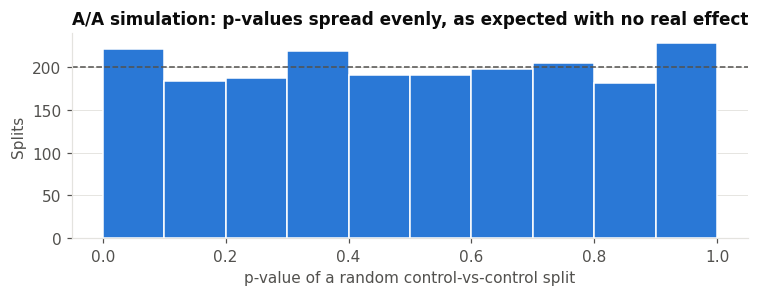

In [11]:
# Check 2: A/A simulation on the control arm
# The number of clicks landing in a random half follows a hypergeometric distribution, so 2,000 splits are instant
rng = np.random.default_rng(42)
N_c, K_c = int(n_ctrl), int(summary.loc['Control', 'clicks'])
n_half = N_c // 2
clicks_a = rng.hypergeometric(K_c, N_c - K_c, n_half, size=2000)
clicks_b = K_c - clicks_a
pa, pb = clicks_a / n_half, clicks_b / (N_c - n_half)
pp = K_c / N_c
z_aa = (pa - pb) / np.sqrt(pp * (1 - pp) * (1 / n_half + 1 / (N_c - n_half)))
p_aa = 2 * stats.norm.sf(np.abs(z_aa))
print(f"A/A false positive rate at alpha = 0.05: {np.mean(p_aa < 0.05):.2%} (expected ~5%)")
print(f"KS test of A/A p-values vs uniform: p = {stats.kstest(p_aa, 'uniform').pvalue:.3f}")

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(p_aa, bins=10, range=(0, 1), color=BLUE, edgecolor='white')
ax.axhline(len(p_aa) / 10, color=INK2, ls='--', lw=1)
ax.set_title('A/A simulation: p-values spread evenly, as expected with no real effect', loc='left')
ax.set_xlabel('p-value of a random control-vs-control split')
ax.set_ylabel('Splits')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

**Findings**

- **The allocation ratio is not stable across days** (chi-square p ≈ 0). Strategy 2 received 11.1% of records on day 1 but only 7.6% on day 2; Strategy 1 went from 9.9% to 12.5%.
- **The baseline moved at the same time:** control CTR almost doubled from 0.96% on day 1 to 1.82% on day 2 (p ≈ 0). Something outside the experiment changed between days (traffic mix, placement, seasonality).
- Together these mean a pooled comparison is confounded by day: Strategy 2 is over-weighted on the low-baseline day. **All effects are therefore also estimated within each day, and combined with a day-stratified estimator** (Section 8).
- **A/A simulation passes:** about 5% false positives at α = 0.05 and uniform p-values, so the testing pipeline itself is sound.

**So what.** Flag the allocation drift to the experimentation platform team before the next test: a shift in traffic split between days usually points to a bucketing or eligibility change mid-test. For this analysis, stratifying by day neutralizes it.

## 7. Hypothesis tests: two independent paths to the same answer

**Question:** Does each strategy beat control on CTR?

**Path 1, by formula** (two-proportion z-test):

- Pooled rate: p̂ = (x₁ + x₂) / (n₁ + n₂)
- Standard error under H0: SE₀ = √( p̂(1 − p̂)(1/n₁ + 1/n₂) )
- z = (p₁ − p₂) / SE₀, two-sided p = 2·(1 − Φ(|z|))
- 95% CI for the difference uses the **unpooled** SE (H0 is not assumed when estimating): SE = √( p₁(1−p₁)/n₁ + p₂(1−p₂)/n₂ )
- Relative lift CI via the log risk ratio: SE(log RR) = √( (1−p₁)/x₁ + (1−p₂)/x₂ )

**Path 2:** `statsmodels.stats.proportion.proportions_ztest`. Both paths must agree.

Why z and not t: the outcome is binary and each arm has tens of thousands of records, so the sampling distribution of a proportion is very close to normal; there is no separate variance parameter to estimate as in a t-test.

In [12]:
def two_prop_test(x_t, n_t, x_c, n_c, alpha_ci=0.05):
    # Rates and difference
    p_t, p_c = x_t / n_t, x_c / n_c
    diff = p_t - p_c
    # Path 1: z by formula with the pooled SE
    p_pool = (x_t + x_c) / (n_t + n_c)
    se0 = np.sqrt(p_pool * (1 - p_pool) * (1 / n_t + 1 / n_c))
    z_manual = diff / se0
    p_manual = 2 * stats.norm.sf(abs(z_manual))
    # Path 2: statsmodels
    z_sm, p_sm = proportions_ztest([x_t, x_c], [n_t, n_c], alternative='two-sided')
    # CI for the absolute difference (unpooled SE)
    zc = stats.norm.ppf(1 - alpha_ci / 2)
    se1 = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
    # CI for the relative lift via log risk ratio
    se_log = np.sqrt((1 - p_t) / x_t + (1 - p_c) / x_c)
    rr = p_t / p_c
    return {'ctr_treat': p_t, 'ctr_ref': p_c, 'abs_diff_pp': diff * 100,
            'rel_lift': rr - 1,
            'z_manual': z_manual, 'z_statsmodels': z_sm, 'p_manual': p_manual, 'p_statsmodels': p_sm,
            'p_bonferroni': min(p_manual * N_COMPARISONS, 1.0),
            'ci95_diff_pp': (round((diff - zc * se1) * 100, 3), round((diff + zc * se1) * 100, 3)),
            'ci95_rel_lift': (round(np.exp(np.log(rr) - zc * se_log) - 1, 3), round(np.exp(np.log(rr) + zc * se_log) - 1, 3)),
            'se_diff': se1}

def compare(data, treat, ref):
    t = data[data.arm == treat].click
    c = data[data.arm == ref].click
    return two_prop_test(t.sum(), len(t), c.sum(), len(c))

COMPARISONS = [('Strategy 1', 'Control'), ('Strategy 2', 'Control'), ('Strategy 2', 'Strategy 1')]
tests = pd.DataFrame([{'comparison': f'{a} vs {b}', **compare(df, a, b)} for a, b in COMPARISONS])
tests['significant_at_bonferroni'] = tests.p_manual < ALPHA
tests['z_paths_agree'] = np.isclose(tests.z_manual, tests.z_statsmodels)
tests.drop(columns='se_diff')

                 comparison  ...  z_paths_agree
0     Strategy 1 vs Control  ...           True
1     Strategy 2 vs Control  ...           True
2  Strategy 2 vs Strategy 1  ...           True

[3 rows x 14 columns]

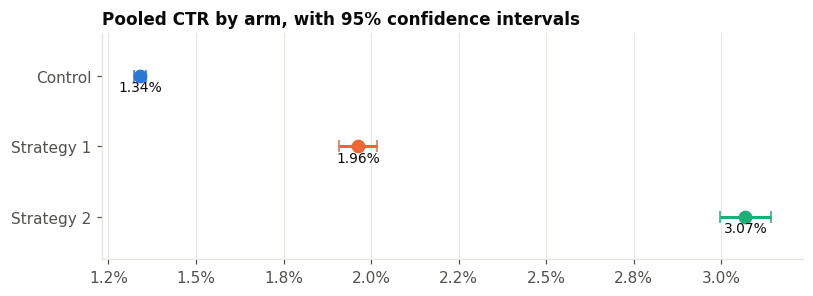

In [13]:
# Chart: pooled CTR per arm with 95% CI
fig, ax = plt.subplots(figsize=(7.5, 2.8))
arms = list(ARM_NAMES.values())
for i, arm in enumerate(arms):
    r = summary.loc[arm]
    se = np.sqrt(r.ctr * (1 - r.ctr) / r.records)
    ax.errorbar(r.ctr * 100, i, xerr=1.96 * se * 100, fmt='o', color=ARM_COLORS[arm], ms=8, capsize=4, lw=2)
    ax.text(r.ctr * 100, i + 0.22, f"{r.ctr:.2%}", ha='center', fontsize=9, color=INK)
ax.set_yticks(range(3))
ax.set_yticklabels(arms)
ax.set_ylim(-0.6, 2.6)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title('Pooled CTR by arm, with 95% confidence intervals', loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

**Pooled result (before the robustness check)**

| Comparison | CTR | Abs. diff | Rel. lift (95% CI) | p (Bonferroni) |
|---|---|---|---|---|
| Strategy 1 vs Control | 1.963% vs 1.340% | +0.62 pp | +46.5% (+42.1%, +51.1%) | < 0.001 |
| Strategy 2 vs Control | 3.069% vs 1.340% | +1.73 pp | +129.1% (+123.0%, +135.4%) | < 0.001 |
| Strategy 2 vs Strategy 1 | 3.069% vs 1.963% | +1.11 pp | +56.3% | < 0.001 |

The formula path and statsmodels agree to every printed digit. Read naively, both strategies win and Strategy 2 wins by more. Section 6 showed why that reading is not yet safe: the pooled numbers mix two very different days.

## 8. Robustness: does the winner win on both days?

**Question:** Is each strategy's lift stable over time, or driven by one day? This is the pre-registered consistency check, and it also plays the role of the "does it win in every segment" question: the dataset has no audience attributes, so **day is the only available split**.

**Methods**

- **Per-day tests:** the same two-proportion test inside each day.
- **Breslow-Day test:** is the effect (odds ratio) the same on both days? A small p-value means the effect is heterogeneous.
- **Day-stratified lift:** average the within-day differences, weighted by each day's share of total traffic. This removes the allocation drift found in Section 6.
- **Cochran-Mantel-Haenszel (CMH) test:** a day-adjusted test of "no effect".

In [14]:
# Per-day tests for both strategies vs control
day_rows = []
for arm in ['Strategy 1', 'Strategy 2']:
    for d in sorted(df.day.unique()):
        res = compare(df[df.day == d], arm, 'Control')
        day_rows.append({'strategy': arm, 'day': d, **res})
by_day = pd.DataFrame(day_rows)
by_day['significant_at_bonferroni'] = by_day.p_manual < ALPHA
by_day[['strategy', 'day', 'ctr_treat', 'ctr_ref', 'abs_diff_pp', 'rel_lift', 'ci95_rel_lift', 'z_manual', 'p_manual', 'significant_at_bonferroni']]

     strategy  day  ctr_treat  ...  z_manual     p_manual  significant_at_bonferroni
0  Strategy 1    1  0.0203501  ...   34.5721 6.63713e-262                       True
1  Strategy 1    2  0.0189041  ...   1.59332     0.111088                      False
2  Strategy 2    1  0.0336389  ...   75.4177            0                       True
3  Strategy 2    2  0.0251879  ...   13.2822  2.93546e-40                       True

[4 rows x 10 columns]

In [15]:
# Day-stratified lift, CMH test, Breslow-Day homogeneity test
day_weights = df.day.value_counts(normalize=True).sort_index()
strat_rows = []
for arm in ['Strategy 1', 'Strategy 2']:
    sub = by_day[by_day.strategy == arm].set_index('day')
    # Weighted average of within-day differences and its standard error
    diff = (sub.abs_diff_pp / 100 * day_weights).sum()
    se = np.sqrt(((sub.se_diff * day_weights) ** 2).sum())
    base = (sub.ctr_ref * day_weights).sum()
    # 2x2 tables per day: rows = treatment / control, columns = click / no click
    tables = []
    for d in sorted(df.day.unique()):
        t = df[(df.day == d) & (df.arm == arm)].click
        c = df[(df.day == d) & (df.arm == 'Control')].click
        tables.append(np.array([[t.sum(), len(t) - t.sum()], [c.sum(), len(c) - c.sum()]]))
    st = StratifiedTable(tables)
    strat_rows.append({
        'strategy': arm,
        'stratified_abs_diff_pp': diff * 100,
        'ci95_pp': (round((diff - 1.96 * se) * 100, 3), round((diff + 1.96 * se) * 100, 3)),
        'stratified_rel_lift': diff / base,
        'cmh_odds_ratio': st.oddsratio_pooled,
        'cmh_p': st.test_null_odds().pvalue,
        'breslow_day_p': st.test_equal_odds().pvalue,
        'positive_on_every_day': bool((sub.abs_diff_pp > 0).all()),
    })
stratified = pd.DataFrame(strat_rows)
stratified

     strategy  stratified_abs_diff_pp  ... breslow_day_p  positive_on_every_day
0  Strategy 1                0.634245  ...             0                   True
1  Strategy 2                 1.65569  ...             0                   True

[2 rows x 8 columns]

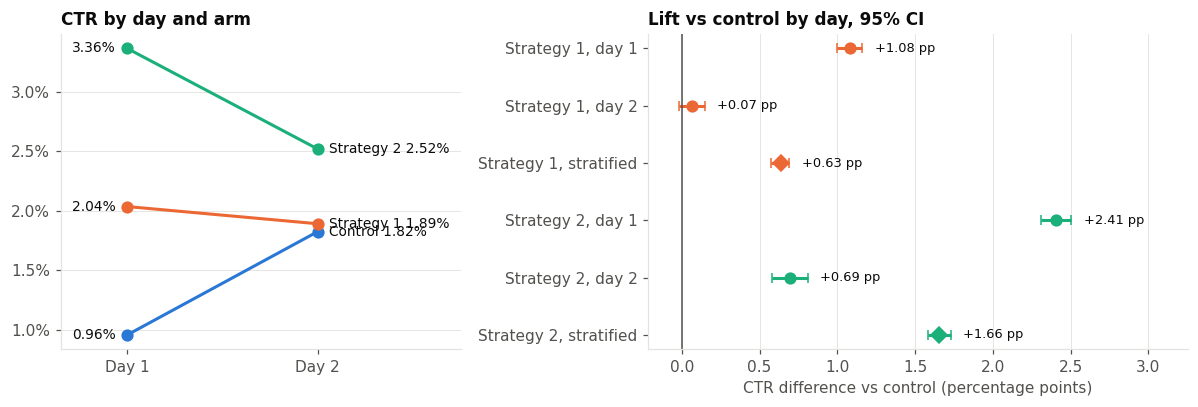

In [16]:
# Chart 1: CTR by day for each arm (shows the baseline jump and Strategy 1 flipping)
ctr_day_arm = df.groupby(['day', 'arm']).click.agg(records='size', clicks='sum', ctr='mean').reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1, 1.35]})
ax = axes[0]
for arm in ARM_NAMES.values():
    s = ctr_day_arm[ctr_day_arm.arm == arm]
    ax.plot(s.day, s.ctr * 100, color=ARM_COLORS[arm], lw=2, marker='o', ms=7)
    ax.text(2.06, s.ctr.iloc[-1] * 100, f"{arm} {s.ctr.iloc[-1]:.2%}", va='center', fontsize=9, color=INK)
    ax.text(0.94, s.ctr.iloc[0] * 100, f"{s.ctr.iloc[0]:.2%}", va='center', ha='right', fontsize=9, color=INK)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Day 1', 'Day 2'])
ax.set_xlim(0.65, 2.75)
ax.yaxis.set_major_locator(mtick.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title('CTR by day and arm', loc='left')
ax.grid(axis='x', visible=False)

# Chart 2: forest plot of absolute difference vs control (pp) with 95% CI
ax = axes[1]
labels, est, lo, hi, cols = [], [], [], [], []
for arm in ['Strategy 1', 'Strategy 2']:
    for _, r in by_day[by_day.strategy == arm].iterrows():
        labels.append(f"{arm}, day {r.day}")
        est.append(r.abs_diff_pp)
        lo.append(r.abs_diff_pp - 1.96 * r.se_diff * 100)
        hi.append(r.abs_diff_pp + 1.96 * r.se_diff * 100)
        cols.append(ARM_COLORS[arm])
    s = stratified.set_index('strategy').loc[arm]
    labels.append(f"{arm}, stratified")
    est.append(s.stratified_abs_diff_pp)
    lo.append(s.ci95_pp[0])
    hi.append(s.ci95_pp[1])
    cols.append(ARM_COLORS[arm])
y = np.arange(len(labels))
for yi, e, l, h_, c, lab in zip(y, est, lo, hi, cols, labels):
    marker = 'D' if 'stratified' in lab else 'o'
    ax.errorbar(e, yi, xerr=[[e - l], [h_ - e]], fmt=marker, color=c, ms=7, capsize=3, lw=2)
    ax.text(h_ + 0.08, yi, f"{e:+.2f} pp", va='center', fontsize=8.5, color=INK)
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(min(lo) - 0.2, max(hi) + 0.75)
ax.set_xlabel('CTR difference vs control (percentage points)')
ax.set_title('Lift vs control by day, 95% CI', loc='left')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

In [17]:
# Sensitivity: same pooled tests with cross-arm users kept in
sens = pd.DataFrame([{'comparison': f'{a} vs {b}', **compare(df_all, a, b)} for a, b in COMPARISONS])
pd.DataFrame({
    'comparison': tests.comparison,
    'rel_lift_main': tests.rel_lift,
    'rel_lift_incl_cross_arm_users': sens.rel_lift,
    'p_main': tests.p_manual,
    'p_incl_cross_arm_users': sens.p_manual,
})

                 comparison  rel_lift_main  ...       p_main  p_incl_cross_arm_users
0     Strategy 1 vs Control       0.465295  ... 4.60163e-132             8.86694e-47
1     Strategy 2 vs Control        1.29096  ...            0                       0
2  Strategy 2 vs Strategy 1        0.56348  ... 2.72638e-127            3.25875e-236

[3 rows x 5 columns]

**Findings**

| | Day 1 | Day 2 | Same effect both days? |
|---|---|---|---|
| Strategy 1 vs Control | **+113%** relative (2.04% vs 0.96%), p < 0.001 | **+3.6%** relative (1.89% vs 1.82%), p = 0.11, not significant | No: Breslow-Day p < 0.001, effect collapses to ~zero |
| Strategy 2 vs Control | **+252%** relative (3.36% vs 0.96%), p < 0.001 | **+38.1%** relative (2.52% vs 1.82%), p < 0.001 | No: Breslow-Day p < 0.001, same sign, much smaller |

- **Strategy 1 fails the pre-registered consistency rule.** Its pooled "win" comes entirely from day 1 (+113%); on day 2 the lift collapses to +3.6% (+0.07 pp, p = 0.11, not significant). Note: the 200k-row development sample read this as −26% and significant — a sampling artifact. Only ~1,300 of the ~197,000 same-day cross-arm user-days are detectable in a 200k-row sample, so undetected cross-arm users contaminated the sample's "clean" analysis. On the full file, with all cross-arm users excluded, the day-2 effect is ~zero, not negative.
- **Strategy 2 is positive on both days**, which satisfies rule (c). Its lift shrinks from +2.41 pp to +0.69 pp (relative +252% → +38.1%, both p < 0.001 on full data). Day-stratified lift: **+1.66 pp (+124% relative)**, CMH p < 0.001.
- A large day-1 effect that fades on day 2 is the typical signature of a **novelty effect** (users click on something new, then habituate) or of a day-specific shock. With two days of data the two cannot be separated, so rollout planning uses the day-2 (post-novelty) figure.t be separated, but either way the **day-2 number is the better guide to steady-state performance**.
- Keeping the 1,362 cross-arm users changes no conclusion.

**So what.** Do not launch Strategy 1. Strategy 2 is the only candidate, but budget should be planned on its day-2 lift (about +13%, still above the 5% MDE as a point estimate), not on the +96% pooled headline.

**Multiple-testing statement.** The primary metric (CTR) and the three comparisons were fixed in Section 1, and every primary p-value is judged at the Bonferroni level α = 0.0167. The per-day tests are the pre-declared consistency check, used for direction rather than as new claims of significance. No other metrics or subgroups were searched.

## 9. Impact estimate

**Question:** What is the rollout worth in clicks?

The dataset contains no impression volume per day, cost or conversion fields, so impact is expressed **per 1 million ad impressions** (user-day records). Two scenarios bracket the outcome:

- **Planning case (day-2 lift):** the most recent, post-novelty estimate.
- **Upper bound (day-stratified lift):** includes the day-1 effect, which may not persist.

In [18]:
# Extra clicks per 1M impressions for Strategy 2 vs control, with 95% CI
s2_day2 = by_day[(by_day.strategy == 'Strategy 2') & (by_day.day == 2)].iloc[0]
s2_strat = stratified.set_index('strategy').loc['Strategy 2']
PER = 1_000_000

impact = pd.DataFrame([
    {'scenario': 'Planning case: day-2 lift',
     'control_ctr': s2_day2.ctr_ref, 'strategy2_ctr': s2_day2.ctr_treat,
     'rel_lift': s2_day2.rel_lift,
     'extra_clicks_per_1M': s2_day2.abs_diff_pp / 100 * PER,
     'ci95_low': (s2_day2.abs_diff_pp / 100 - 1.96 * s2_day2.se_diff) * PER,
     'ci95_high': (s2_day2.abs_diff_pp / 100 + 1.96 * s2_day2.se_diff) * PER},
    {'scenario': 'Upper bound: day-stratified lift',
     'control_ctr': np.nan, 'strategy2_ctr': np.nan,
     'rel_lift': s2_strat.stratified_rel_lift,
     'extra_clicks_per_1M': s2_strat.stratified_abs_diff_pp / 100 * PER,
     'ci95_low': s2_strat.ci95_pp[0] / 100 * PER,
     'ci95_high': s2_strat.ci95_pp[1] / 100 * PER},
])
impact['exceeds_5pct_mde'] = impact.rel_lift > MDE_REL
impact.round(4)

                           scenario  control_ctr  ...  ci95_high  exceeds_5pct_mde
0         Planning case: day-2 lift       0.0182  ...   8,109.56              True
1  Upper bound: day-stratified lift          NaN  ...     17,300              True

[2 rows x 8 columns]

In [19]:
# Conversions depend on a click-to-conversion rate the dataset does not contain
# Illustrative only: replace CVR with the real historical value before using these numbers
CVR_SCENARIOS = [0.01, 0.02, 0.05]
conv = pd.DataFrame({f'assumed_cvr_{int(c * 100)}pct': impact.extra_clicks_per_1M * c for c in CVR_SCENARIOS})
conv.insert(0, 'scenario', impact.scenario)
conv.round(0)

                           scenario  ...  assumed_cvr_5pct
0         Planning case: day-2 lift  ...               347
1  Upper bound: day-stratified lift  ...               828

[2 rows x 4 columns]

**Takeaway.** Planning case: about **+6,900 extra clicks per million impressions** (+38.1%), with a 95% CI from roughly 5,800 to 8,100. Upper bound: about **+16,600 per million** (+124%). The point estimate in both scenarios is above the 5% MDE. Turning clicks into conversions or revenue requires the historical click-to-conversion rate and the cost per impression of each strategy, which are not in this dataset; the conversion table above is a template, not a result.

## 10. Decision memo

> **To:** Head of Marketing  **Re:** Ad targeting strategy test, rollout decision

**Recommendation.** Roll out **Strategy 2** in stages, starting at 50% of traffic with a 10% control holdout kept for two weeks. **Stop Strategy 1.**

**Why**

- Strategy 2 beat the current strategy on both days of the test. Pooled CTR 3.07% vs 1.34% (+129%, p < 0.001); after adjusting for a traffic-split change between days, +1.66 pp (+124%).
- The gain shrank sharply from day 1 (+252%) to day 2 (+38.1%). That looks like users reacting to something new and then settling, so **plan on the day-2 figure (about +38%), not the headline**.
- Strategy 1 looked like a +47% winner overall, but its lift comes entirely from day 1 (+113%); on day 2 it is +3.6% and not statistically significant. It is not reliable.

**Expected impact.** About +6,900 extra clicks per million impressions at the day-2 lift (95% CI 5,800 to 8,100); up to +16,600 if the day-1 effect partly persists. Incremental cost and conversions depend on the cost per impression and conversion rate of Strategy 2, which this test did not measure; finance should confirm cost per click is not higher before going above 50%.

**What we will monitor (daily, for 2 weeks)**

- CTR of Strategy 2 vs the 10% holdout, with a 7-day rolling 95% CI.
- Downstream: conversion rate and cost per click (not measured in this test).
- Traffic split: confirm the holdout stays at the planned share every day (this test's split drifted between days).

**When we roll back**

- If the rolling relative lift falls below the 5% MDE for 7 consecutive days, or its 95% CI lies entirely below zero at any weekly review, return to the current strategy.
- If cost per click rises above the current strategy's.

**Go to 100%** once the two-week holdout shows a lift at or above 5% with a 95% CI that excludes zero.

**Limitations**

- Only CTR was measured: no conversions, revenue or long-term retention.
- Two days of data: novelty effect and a day-specific shock cannot be told apart.
- Traffic split changed between days and the control baseline doubled; the analysis adjusts for this, but the root cause should be found.
- 8.33% of users appeared in more than one arm on the same day and were excluded; results including them are reported as a sensitivity check and do not change the decision.
- No audience attributes: the test cannot say whether some audiences prefer the current strategy.

## 11. Export summary tables for the Power BI dashboard

| File | Dashboard page |
|---|---|
| `kpi_summary.csv` | 1. Decision page (KPI cards + recommendation) |
| `ctr_by_arm.csv` | 2. Comparison page (CTR with 95% CI error bars) |
| `effect_by_day.csv`, `stratified_effects.csv` | 3. Heterogeneity page (forest plot) |
| `ctr_by_day_arm.csv` | 4. Trend page (CTR by day per arm) |
| `tests.csv`, `impact.csv` | Supporting tables |

In [20]:
# CTR per arm with CI bounds (ready for error bars)
ctr_by_arm = summary.reset_index().rename(columns={'index': 'arm'})
ctr_by_arm['se'] = np.sqrt(ctr_by_arm.ctr * (1 - ctr_by_arm.ctr) / ctr_by_arm.records)
ctr_by_arm['ci95_low'] = ctr_by_arm.ctr - 1.96 * ctr_by_arm.se
ctr_by_arm['ci95_high'] = ctr_by_arm.ctr + 1.96 * ctr_by_arm.se

# Forest-plot table: one row per strategy x day with CI bounds in pp
effect_by_day = by_day[['strategy', 'day', 'ctr_treat', 'ctr_ref', 'abs_diff_pp', 'rel_lift', 'p_manual']].copy()
effect_by_day['ci95_low_pp'] = by_day.abs_diff_pp - 1.96 * by_day.se_diff * 100
effect_by_day['ci95_high_pp'] = by_day.abs_diff_pp + 1.96 * by_day.se_diff * 100

# Headline KPIs
s2 = tests.set_index('comparison').loc['Strategy 2 vs Control']
kpi_summary = pd.DataFrame([
    ('Records analyzed', len(df)),
    ('Control CTR', summary.loc['Control', 'ctr']),
    ('Strategy 1 CTR', summary.loc['Strategy 1', 'ctr']),
    ('Strategy 2 CTR', summary.loc['Strategy 2', 'ctr']),
    ('Strategy 2 pooled relative lift', s2.rel_lift),
    ('Strategy 2 pooled p-value', s2.p_manual),
    ('Strategy 2 day-stratified relative lift', s2_strat.stratified_rel_lift),
    ('Strategy 2 day-2 relative lift (planning case)', s2_day2.rel_lift),
    ('Strategy 1 day-2 relative lift', by_day[(by_day.strategy == 'Strategy 1') & (by_day.day == 2)].rel_lift.iloc[0]),
    ('Required records per arm for 5% MDE', round(n_equal)),
    ('Decision', 'Staged rollout of Strategy 2; stop Strategy 1'),
], columns=['kpi', 'value'])

exports = {
    'kpi_summary': kpi_summary, 'ctr_by_arm': ctr_by_arm, 'ctr_by_day_arm': ctr_day_arm,
    'effect_by_day': effect_by_day, 'stratified_effects': stratified,
    'tests': tests.drop(columns='se_diff'), 'impact': impact,
}
for name, t in exports.items():
    t.to_csv(f'{OUTPUT_DIR}/{name}.csv', index=False)
print(sorted(os.listdir(OUTPUT_DIR)))
kpi_summary

['ctr_by_arm.csv', 'ctr_by_day_arm.csv', 'effect_by_day.csv', 'impact.csv', 'kpi_summary.csv', 'stratified_effects.csv', 'tests.csv']


                                               kpi                                          value
0                                 Records analyzed                                        2219999
1                                      Control CTR                                      0.0133975
2                                   Strategy 1 CTR                                      0.0196313
3                                   Strategy 2 CTR                                      0.0306932
4                  Strategy 2 pooled relative lift                                        1.29096
5                        Strategy 2 pooled p-value                                              0
6          Strategy 2 day-stratified relative lift                                        1.23808
7   Strategy 2 day-2 relative lift (planning case)                                       0.380543
8                   Strategy 1 day-2 relative lift                                      0.0361307
9              Requi

## 12. Summary, limitations & next steps

All figures come from the full 2,645,958-row file (2,219,999 records after excluding cross-arm users).

| Step | Result |
|---|---|
| Schema check | `channel` column = experiment arm (dmp_id), `strategy` column = day (dt); 3-arm test, not 2-arm |
| Power | 5% MDE needs ~632k records per arm; the full file detects ~6-6.5% lifts |
| Randomization | Traffic split drifted between days (chi-square p ≈ 0) while control CTR doubled; A/A simulation clean (~5% false positives) |
| Pooled test | Strategy 1 +46.5%, Strategy 2 +129.1% vs control, both p < 0.001; formula and statsmodels agree |
| By day | Strategy 1: +113% day 1, +3.6% day 2 (p = 0.11, ns — effect collapses to ~zero). Strategy 2: +252% day 1, +38.1% day 2 (p < 0.001) |
| Day-stratified | Strategy 2 +1.66 pp (+124%), CMH p < 0.001 |
| Impact | Strategy 2: ~+6,900 clicks per 1M impressions (planning case), up to ~+16,600 (upper bound) |
| Decision | Staged rollout of Strategy 2 with a 10% holdout; stop Strategy 1 |

**Next steps**

1. Run the two-week holdout sized for the 5% MDE (~632k records per arm) to confirm the steady-state lift.
2. Add conversion, revenue and cost per click to the experiment logging, so the next decision is made on profit, not clicks.
3. Log audience attributes (new vs returning, device, placement) to test whether some audiences prefer the current strategy.
4. Investigate why the traffic split and the baseline CTR changed between day 1 and day 2.